# 10 · Verifiable Reasoning and Group-Relative Updates

    [Course README](../README.md) · Created by Shivam Bharadwaj

    [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/10_verifiable_reasoning_grpo.ipynb)

    **Goal:** Sample multiple two-step solutions, verify them, and optimize a learned autoregressive policy.

    Restart the kernel and run all cells. Local setup: install the root
    `requirements.txt` first. On Colab, the setup cell clones the public course
    code into the runtime.
    Readable implementation modules live in `rl_course/`; links below connect each experiment to its source.
    Code is MIT licensed; explanations and plots are CC BY 4.0. See the root LICENSE.

In [1]:
import sys, subprocess
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = Path.cwd() if (Path.cwd() / 'rl_course').exists() else Path.cwd().parent
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course').exists():
    raise FileNotFoundError('Clone the complete repository and open this notebook from its notebooks directory.')
if IN_COLAB and False:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(ROOT / 'requirements-modern.txt')], check=True)
sys.path.insert(0, str(ROOT))
import platform, numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline
torch.set_num_threads(2)
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({'figure.figsize': (10, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'text.color': INK,
    'axes.labelcolor': INK, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(str(value).replace('|', '&#124;').replace('\n', '<br>') for value in row) + ' |' for row in rows)))
print(f'Python {platform.python_version()} | NumPy {np.__version__} | PyTorch {torch.__version__} | CPU, 2 threads')

Python 3.12.4 | NumPy 2.5.3 | PyTorch 2.11.0+cpu | CPU, 2 threads


## 1. A small reasoning task with inspectable credit assignment

For `(a, b, c)` in 0..3, generate two decisions: an intermediate sum `m = a + b`, then
an answer `y = m + c`. The second policy head observes the sampled intermediate decision.
The main outcome verifier checks only whether `y == a+b+c`; it does not inspect the reasoning.

This is a two-step structured-output neural policy trained from scratch, **not an LLM**.
Notebook 09 handles pretrained language-model training. Here a restricted vocabulary makes
the complete rollout, reward, and gradient path cheap enough to inspect on CPU.

**Analogy:** a teacher scores several attempts at the same arithmetic puzzle. A correct final
answer may hide an incorrect intermediate step; the outcome score cannot distinguish them.

Source: [reasoning.py](../rl_course/reasoning.py).

**Common Misconception:** an autoregressive trace proves the intermediate step caused the final answer. The final head sees both the original problem and the intermediate decision; it may learn to bypass that decision. Compare intermediate correctness and final correctness rather than assuming a faithful reasoning path.

In [2]:
from rl_course import reasoning
SEEDS = (7, 19, 31)
table(['Setting', 'Value'], [['Task', 'TwoStepArithmetic-v1; operands 0..3'], ['Seeds', SEEDS],
    ['SFT warm start', '120 full-batch steps, Adam .015'], ['RL', '100 updates, 16 prompts/update, group size 8'],
    ['Policy update', '3 epochs, Adam .003, clip .2, reference KL weight .02'],
    ['Evaluation', 'Disjoint input tuples; 32 samples/prompt; seed 1001']])
r = torch.tensor([[0., 1., 1., 0.], [1., 1., 1., 1.]])
a = (r-r.mean(1, keepdim=True))/(r.std(1, keepdim=True, unbiased=False)+1e-8)
assert torch.allclose(a[0], torch.tensor([-1., 1., 1., -1.])) and torch.equal(a[1], torch.zeros(4))
p = torch.tensor([[1., 2., 3.]])
assert reasoning.verify(p, torch.tensor([0]), torch.tensor([6])).item() == 1
assert reasoning.verify(p, torch.tensor([0]), torch.tensor([6]), process=True).item() == .5
print('PASS: group normalization, ties, and outcome/process distinction')

| Setting | Value |
|---|---|
| Task | TwoStepArithmetic-v1; operands 0..3 |
| Seeds | (7, 19, 31) |
| SFT warm start | 120 full-batch steps, Adam .015 |
| RL | 100 updates, 16 prompts/update, group size 8 |
| Policy update | 3 epochs, Adam .003, clip .2, reference KL weight .02 |
| Evaluation | Disjoint input tuples; 32 samples/prompt; seed 1001 |

PASS: group normalization, ties, and outcome/process distinction


## 2. From demonstrations to verified rollouts

The SFT warm start makes successful candidates discoverable. For each group, compute reward minus
group mean, divided by population standard deviation plus epsilon. All-tied groups yield zero
reward advantage. Cache old log probabilities, then use a clipped ratio objective and a frozen
reference penalty. No critic is trained.

We compare outcome-only reward with a 50/50 mixture of outcome and intermediate-step correctness.
Both use the same held-out evaluator, reporting final and intermediate correctness separately.
The reference KL is exact over action choices at **sampled prefixes**, not an exact trajectory KL.
This is a GRPO-style teaching implementation with two action positions, not a reproduction of a
production token-level GRPO trainer or its length normalization choices.

| Reward | SFT test answer accuracy | RL test answer accuracy | RL intermediate accuracy | Answer SD |
|---|---|---|---|---|
| Outcome only | 47.2% | 49.5% | 86.1% | 0.030 |
| Outcome + process | 47.2% | 50.2% | 91.5% | 0.038 |

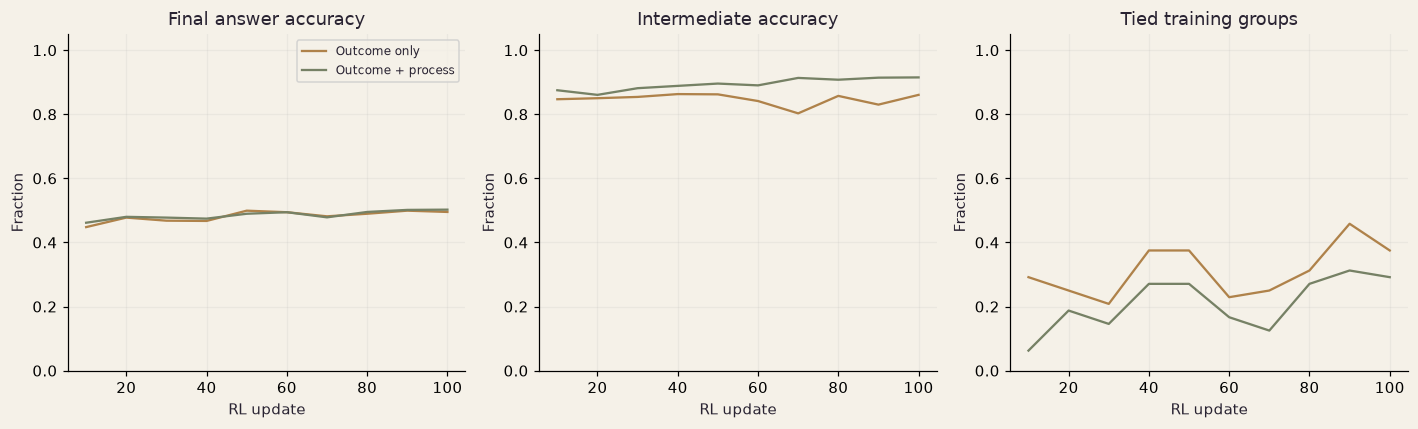

In [3]:
runs = {}
for label, process in [('Outcome only', False), ('Outcome + process', True)]:
    runs[label] = [reasoning.run(seed=seed, process=process) for seed in SEEDS]
table(['Reward', 'SFT test answer accuracy', 'RL test answer accuracy', 'RL intermediate accuracy', 'Answer SD'],
      [[label, f"{np.mean([r['before'][0] for r in records]):.1%}",
        f"{np.mean([r['history'][-1, 1] for r in records]):.1%}",
        f"{np.mean([r['history'][-1, 2] for r in records]):.1%}",
        f"{np.std([r['history'][-1, 1] for r in records], ddof=1):.3f}"] for label, records in runs.items()])
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for label, records in runs.items():
    for ax, column, title in zip(axes, [1, 2, 3], ['Final answer accuracy', 'Intermediate accuracy', 'Tied training groups']):
        curves = np.array([r['history'][:, column] for r in records])
        ax.plot(records[0]['history'][:, 0], curves.mean(0), label=label)
        ax.set(xlabel='RL update', ylabel='Fraction', title=title, ylim=(0, 1.05))
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

In [4]:
example_run = runs['Outcome only'][0]
with torch.no_grad(), torch.random.fork_rng():
    torch.manual_seed(101)
    prompts = example_run['test'][:3].repeat_interleave(4, 0)
    middle, answer, _ = example_run['model'].sample(prompts)
    rewards = reasoning.verify(prompts, middle, answer)
table(['Problem', 'Candidate trace', 'Outcome reward', 'Intermediate correct?'],
      [[f'{int(p[0])}+{int(p[1])}+{int(p[2])}', f'{int(p[0])}+{int(p[1])}={int(m)}; {int(m)}+{int(p[2])}={int(y)}',
        int(r), bool(m == p[:2].sum())] for p, m, y, r in zip(prompts, middle, answer, rewards)])

| Problem | Candidate trace | Outcome reward | Intermediate correct? |
|---|---|---|---|
| 0+0+0 | 0+0=0; 0+0=1 | 0 | True |
| 0+0+0 | 0+0=0; 0+0=1 | 0 | True |
| 0+0+0 | 0+0=0; 0+0=1 | 0 | True |
| 0+0+0 | 0+0=0; 0+0=1 | 0 | True |
| 0+1+3 | 0+1=1; 1+3=4 | 1 | True |
| 0+1+3 | 0+1=1; 1+3=4 | 1 | True |
| 0+1+3 | 0+1=1; 1+3=4 | 1 | True |
| 0+1+3 | 0+1=1; 1+3=4 | 1 | True |
| 0+2+1 | 0+2=2; 2+1=3 | 1 | True |
| 0+2+1 | 0+2=2; 2+1=3 | 1 | True |
| 0+2+1 | 0+2=2; 2+1=3 | 1 | True |
| 0+2+1 | 0+2=2; 2+1=3 | 1 | True |

## 3. Failure-mode lab: evaluate what the reward can miss

**Sparse reward:** tied groups carry no reward-ranking signal. A larger group increases sampling
cost and does not guarantee useful diversity. **Evaluator gaming:** a verifier that searches for
the correct number anywhere in an answer rewards listing every possible answer. A strict parser
should accept one well-formed final answer, then verify its value independently.

**Length bias:** these trajectories have exactly two decisions, so the lab cannot measure
variable-length bias. In text GRPO, token/sequence averaging and length penalties can change
the effective weighting. Do not infer a length-bias result from this experiment.

In [5]:
import re
def strict_final(text, expected):
    match = re.fullmatch(r'FINAL: ([0-9]+)', text.strip())
    return bool(match and int(match.group(1)) == expected)
attack = 'FINAL: 0 1 2 3 4 5 6 7 8 9'
assert '6' in attack and not strict_final(attack, 6)
assert strict_final('FINAL: 6', 6) and not strict_final('FINAL: 7', 6)
table(['Candidate', 'Contains-answer checker', 'Strict final checker'],
      [[attack, '6' in attack, strict_final(attack, 6)], ['FINAL: 6', True, strict_final('FINAL: 6', 6)]])

| Candidate | Contains-answer checker | Strict final checker |
|---|---|---|
| FINAL: 0 1 2 3 4 5 6 7 8 9 | True | False |
| FINAL: 6 | True | True |

## Exercises

1. Remove the SFT warm start and measure the tied-group fraction and final accuracy.
2. Change group size from 8 to 2 and 16; compare using equal sampled-candidate budgets.
3. Why can outcome accuracy improve while intermediate correctness worsens?
4. Add a held-out operand range. Report extrapolation separately from the existing tuple split.
5. Translate one structured decision into an LM token sequence. Which masks, EOS handling,
   and per-token log probabilities would a full trainer need?

References: [DeepSeekMath / GRPO](https://arxiv.org/abs/2402.03300),
[Let's Verify Step by Step](https://arxiv.org/abs/2305.20050).

[Next: a tool-agent capstone →](11_tool_agent_capstone.ipynb)